# PR-11: Real-Data Probe Evaluation

Analyses linear probe scores trained on real GIFT-Eval data (pseudo-labels).
Results come from `train_probes_real.py` and are stored in `results/real/`.

## Features probed

| Group | Feature | Type | Baseline |
|-------|---------|------|----------|
| Trend/Season | `stl_trend_strength` | Regression (R²) | 0.0 |
| Trend/Season | `stl_seasonal_strength` | Regression (R²) | 0.0 |
| Spectral | `fft_dominant_period` | Regression (R²) | 0.0 |
| Spectral | `fft_top1_power_frac` | Regression (R²) | 0.0 |
| Spectral | `spectral_flatness` | Regression (R²) | 0.0 |
| Stationarity | `adf_pvalue` | Regression (R²) | 0.0 |
| Stationarity | `hurst_exponent` | Regression (R²) | 0.0 |
| Complexity | `sample_entropy` | Regression (R²) | 0.0 |
| Complexity | `n_changepoints` | Regression (R²) | 0.0 |
| Basic stats | `context_std` | Regression (R²) | 0.0 |
| Basic stats | `context_acf_lag1` | Regression (R²) | 0.0 |
| Sanity | `dataset_id` | Classification (accuracy) | 0.1111 (9-class chance) |

Results auto-loaded from `results/real/`. The notebook prints a clear message if results aren't ready yet.

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', '..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

NOTEBOOK_DIR = Path(os.path.abspath('__file__')).parent
RESULTS_DIR  = NOTEBOOK_DIR / 'results' / 'real'
FIGURES_DIR  = NOTEBOOK_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

print(f'Results dir : {RESULTS_DIR}')
print(f'Figures dir : {FIGURES_DIR}')

Results dir : /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/results/real
Figures dir : /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures


## Load results

In [2]:
MODELS = ['moiraie', 'moiraic']
MODEL_LABELS = {'moiraie': 'Encoder (moiraie)', 'moiraic': 'Decoder (moiraic)'}

def _load_results(path):
    """Load probe JSON, converting string layer keys to ints at the innermost level."""
    with open(path) as f:
        raw = json.load(f)
    return {
        pooling: {
            feat: {int(k): v for k, v in layers.items()}
            for feat, layers in feat_dict.items()
        }
        for pooling, feat_dict in raw.items()
    }

# Check whether results exist yet
missing = [m for m in MODELS if not (RESULTS_DIR / f'{m}.json').exists()]
if missing:
    print(f'Results not ready yet — missing: {missing}')
    print(f'Run train_probes_real.py and re-execute this notebook when complete.')
    RESULTS_READY = False
else:
    RESULTS_READY = True

if RESULTS_READY:
    data = {m: _load_results(RESULTS_DIR / f'{m}.json') for m in MODELS}

    meta_path = RESULTS_DIR / 'metadata.json'
    with open(meta_path) as f:
        feature_meta = json.load(f)['features']

    # Feature and layer discovery
    POOLINGS = ['mean_ctx', 'last_ctx']
    sample_pooling = data[MODELS[0]]['mean_ctx']
    ALL_FEATURES = list(sample_pooling.keys())
    LAYERS = sorted(next(iter(sample_pooling.values())).keys())

    print(f'Models   : {MODELS}')
    print(f'Features : {ALL_FEATURES}')
    print(f'Layers   : {LAYERS}')

    # Feature groups for grouped plots
    FEATURE_GROUPS = {
        'Trend / Season': ['stl_trend_strength', 'stl_seasonal_strength'],
        'Spectral':       ['fft_dominant_period', 'fft_top1_power_frac', 'spectral_flatness'],
        'Stationarity':   ['adf_pvalue', 'hurst_exponent'],
        'Complexity':     ['sample_entropy', 'n_changepoints'],
        'Basic stats':    ['context_std', 'context_acf_lag1'],
        'Sanity':         ['dataset_id'],
    }
    # Only keep features that are actually in results
    FEATURE_GROUPS = {g: [f for f in fs if f in ALL_FEATURES]
                      for g, fs in FEATURE_GROUPS.items()}
    FEATURE_GROUPS = {g: fs for g, fs in FEATURE_GROUPS.items() if fs}

    prop_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    MODEL_COLORS = {m: prop_cycle[i] for i, m in enumerate(MODELS)}

Models   : ['moiraie', 'moiraic']
Features : ['stl_trend_strength', 'stl_seasonal_strength', 'fft_dominant_period', 'fft_top1_power_frac', 'spectral_flatness', 'adf_pvalue', 'hurst_exponent', 'sample_entropy', 'n_changepoints', 'context_std', 'context_acf_lag1', 'dataset_id']
Layers   : [-1, 0, 1, 2, 3, 4, 5, 6, 7]


## 1. Layer-by-layer probe scores (mean_ctx)

One subplot per feature. Dashed line = chance baseline. Layer −1 is the post-projection embedding before any transformer block.

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_probe_stl_trend_strength.pdf


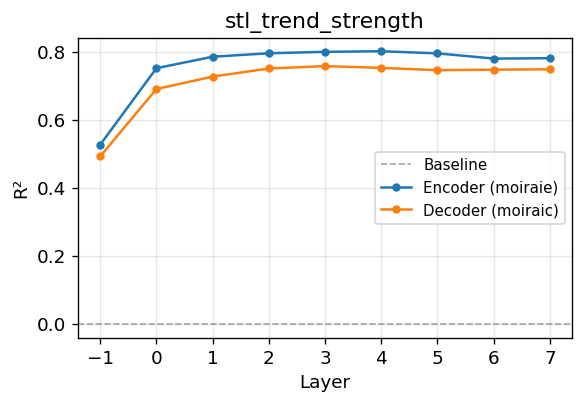

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_probe_stl_seasonal_strength.pdf


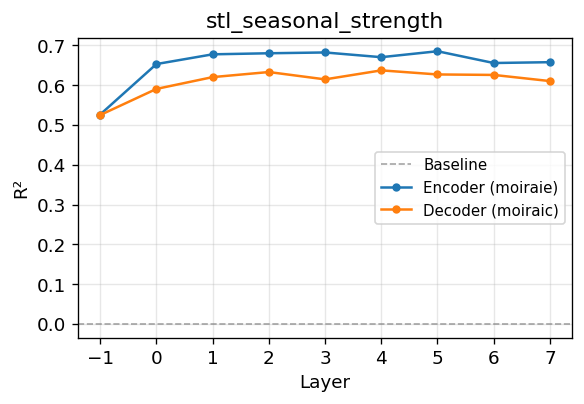

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_probe_fft_dominant_period.pdf


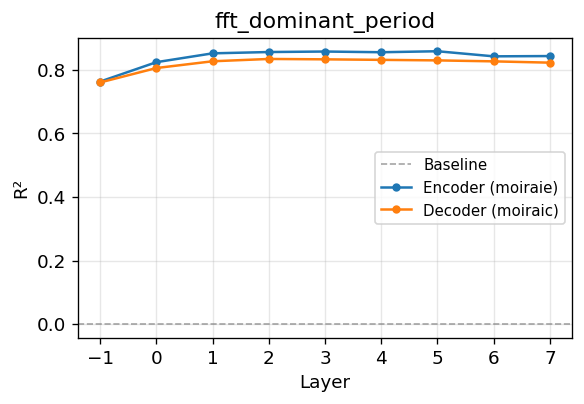

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_probe_fft_top1_power_frac.pdf


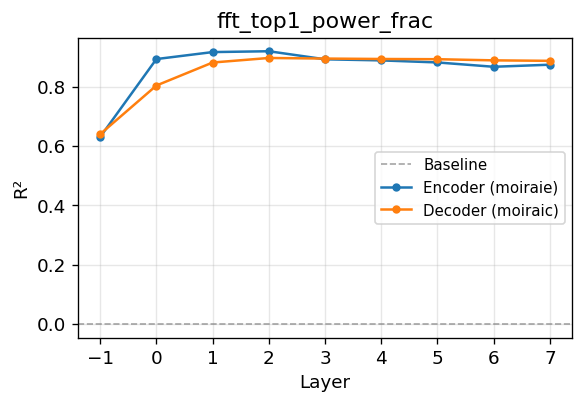

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_probe_spectral_flatness.pdf


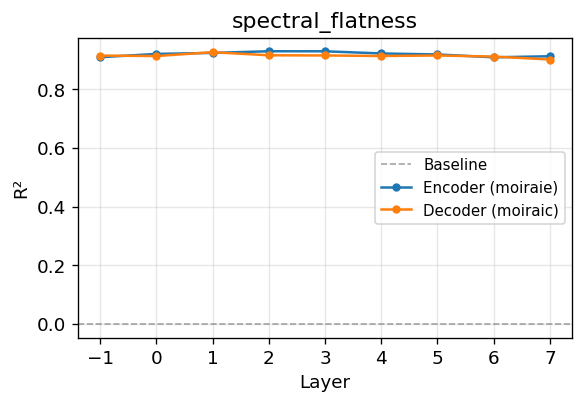

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_probe_adf_pvalue.pdf


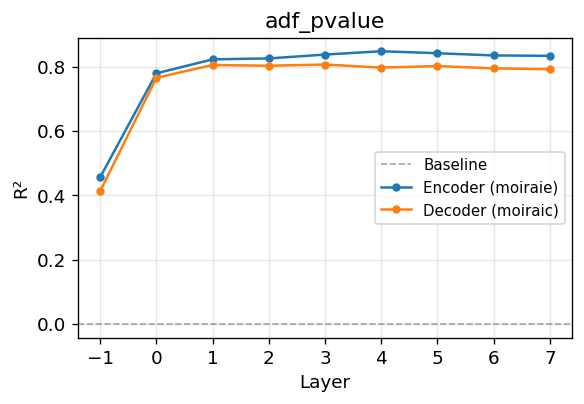

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_probe_hurst_exponent.pdf


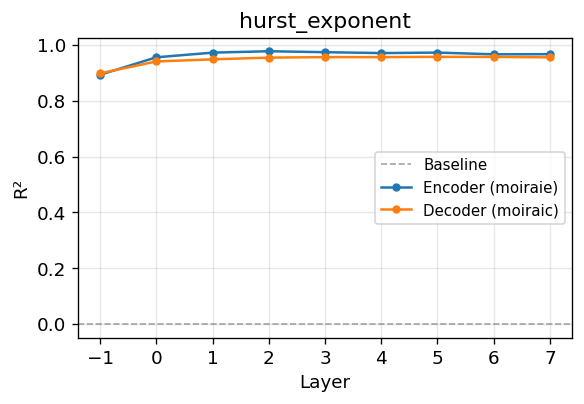

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_probe_sample_entropy.pdf


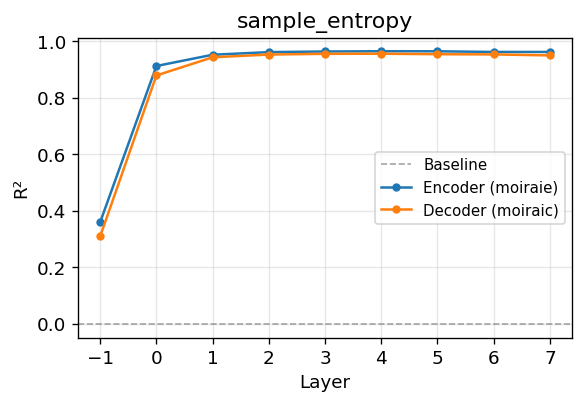

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_probe_n_changepoints.pdf


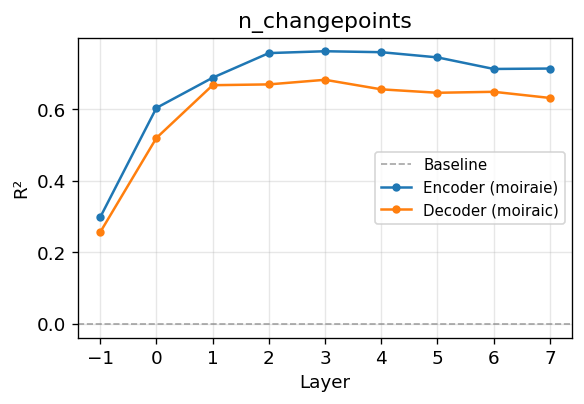

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_probe_context_std.pdf


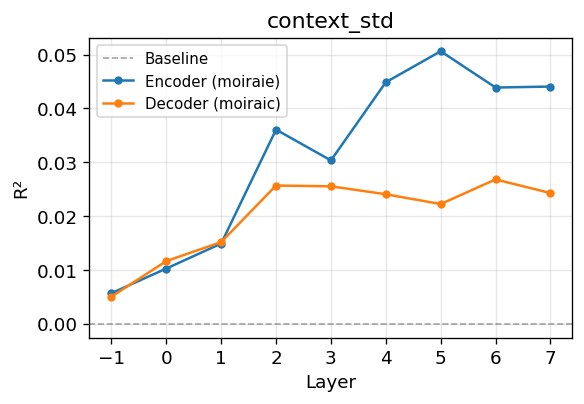

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_probe_context_acf_lag1.pdf


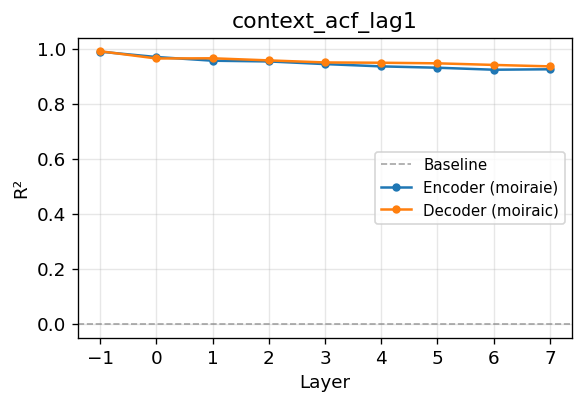

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_probe_dataset_id.pdf


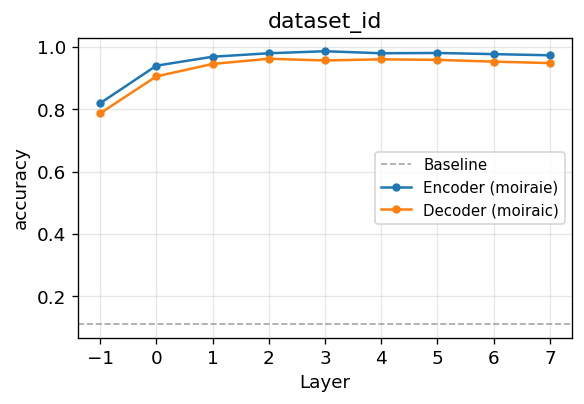

In [3]:
if not RESULTS_READY:
    print('No results yet — skipping.')
else:
    POOLING = 'mean_ctx'
    REG_FEATURES = [f for f in ALL_FEATURES if feature_meta[f]['type'] == 'regression']
    CLF_FEATURES = [f for f in ALL_FEATURES if feature_meta[f]['type'] == 'classification']

    for feature in REG_FEATURES + CLF_FEATURES:
        meta = feature_meta[feature]
        baseline = meta['baseline']
        metric_label = meta['metric']

        fig, ax = plt.subplots(figsize=(5, 3.5))
        ax.axhline(baseline, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Baseline')

        for m in MODELS:
            if feature not in data[m][POOLING]:
                continue
            scores = [data[m][POOLING][feature].get(l, np.nan) for l in LAYERS]
            ax.plot(LAYERS, scores, marker='o', markersize=4,
                    color=MODEL_COLORS[m], label=MODEL_LABELS[m])

        ax.set_xlabel('Layer')
        ax.set_ylabel(f'{metric_label}')
        ax.set_title(feature)
        ax.set_xticks(LAYERS)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()

        save_path = FIGURES_DIR / f'pr11_probe_{feature}.pdf'
        fig.savefig(save_path, bbox_inches='tight')
        print(f'Saved {save_path}')
        plt.show()
        plt.close(fig)

## 2. Overview heatmap: all features × all layers (mean_ctx)

Rows = features, columns = layers. Color = score minus baseline (so zero = chance).
One heatmap per model, side by side.

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_heatmap_overview.pdf


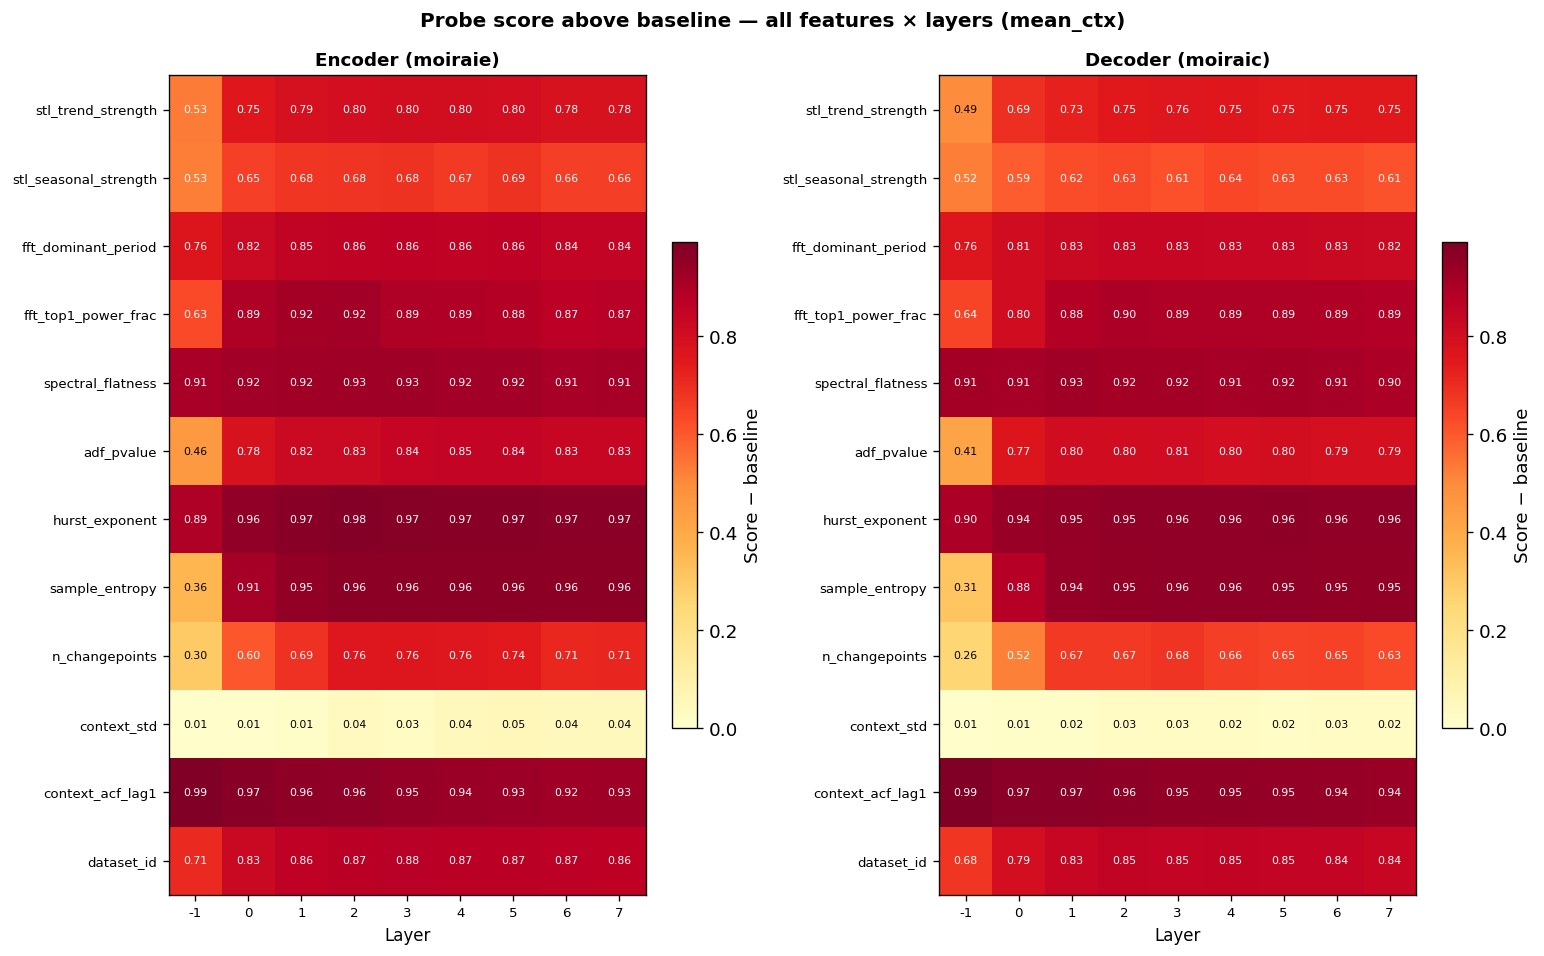

In [4]:
if not RESULTS_READY:
    print('No results yet — skipping.')
else:
    POOLING = 'mean_ctx'

    def _build_score_matrix(model, pooling, features, layers):
        mat = np.full((len(features), len(layers)), np.nan)
        for i, feat in enumerate(features):
            meta = feature_meta[feat]
            if feat not in data[model][pooling]:
                continue
            for j, l in enumerate(layers):
                raw = data[model][pooling][feat].get(l, np.nan)
                mat[i, j] = raw - meta['baseline']  # excess over baseline
        return mat

    display_features = [f for f in ALL_FEATURES]  # all features in result order

    fig, axes = plt.subplots(1, 2, figsize=(13, 0.55 * len(display_features) + 1.5))
    vmax = max(
        np.nanmax(_build_score_matrix(m, POOLING, display_features, LAYERS))
        for m in MODELS
    )
    vmax = max(vmax, 0.05)

    for ax, m in zip(axes, MODELS):
        mat = _build_score_matrix(m, POOLING, display_features, LAYERS)
        im = ax.imshow(mat, aspect='auto', cmap='YlOrRd', vmin=0, vmax=vmax,
                       interpolation='nearest')
        ax.set_xticks(range(len(LAYERS)))
        ax.set_xticklabels([str(l) for l in LAYERS], fontsize=8)
        ax.set_yticks(range(len(display_features)))
        ax.set_yticklabels(display_features, fontsize=8)
        ax.set_xlabel('Layer', fontsize=10)
        ax.set_title(MODEL_LABELS[m], fontsize=11, fontweight='bold')
        # Annotate cells with value
        for i in range(len(display_features)):
            for j in range(len(LAYERS)):
                v = mat[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                            fontsize=6.5, color='black' if v < 0.5 * vmax else 'white')
        plt.colorbar(im, ax=ax, label='Score − baseline', fraction=0.046)

    fig.suptitle(f'Probe score above baseline — all features × layers ({POOLING})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    save_path = FIGURES_DIR / 'pr11_heatmap_overview.pdf'
    fig.savefig(save_path, bbox_inches='tight')
    print(f'Saved {save_path}')
    plt.show()

## 3. Grouped curves: features by semantic category

Each panel shows features from the same group on a single axes for easy comparison.
Solid lines = moiraie (encoder), dashed = moiraic (decoder).

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_group_trend__season.pdf


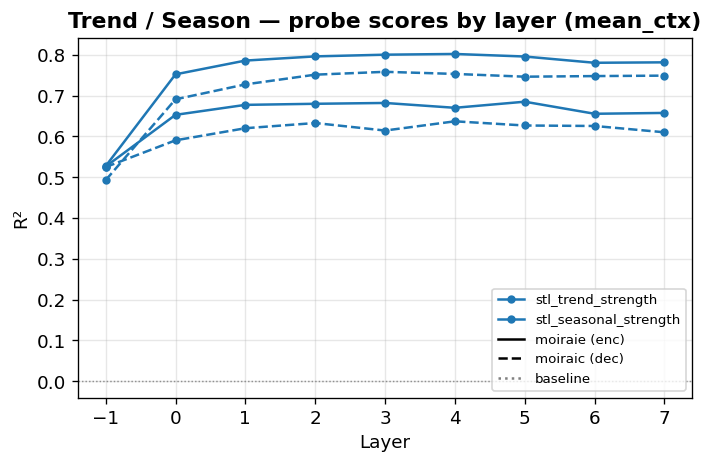

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_group_spectral.pdf


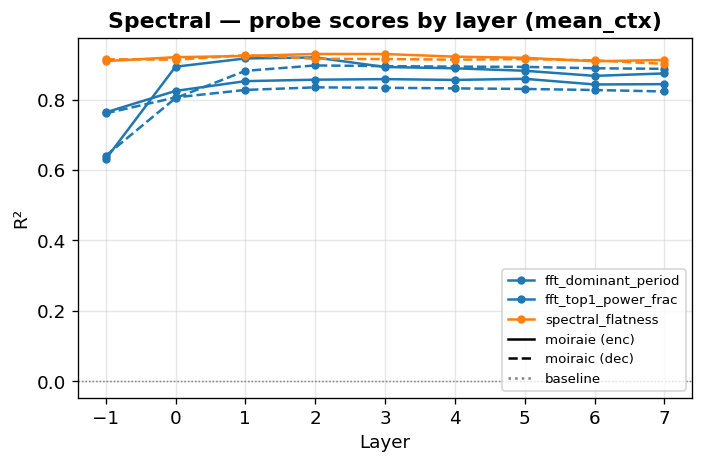

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_group_stationarity.pdf


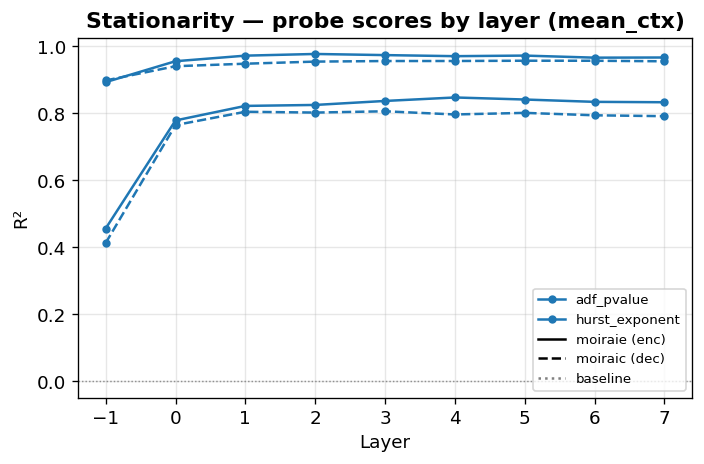

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_group_complexity.pdf


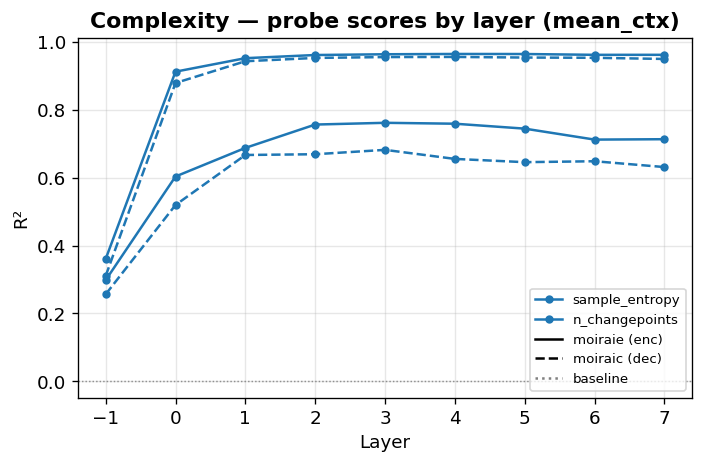

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_group_basic_stats.pdf


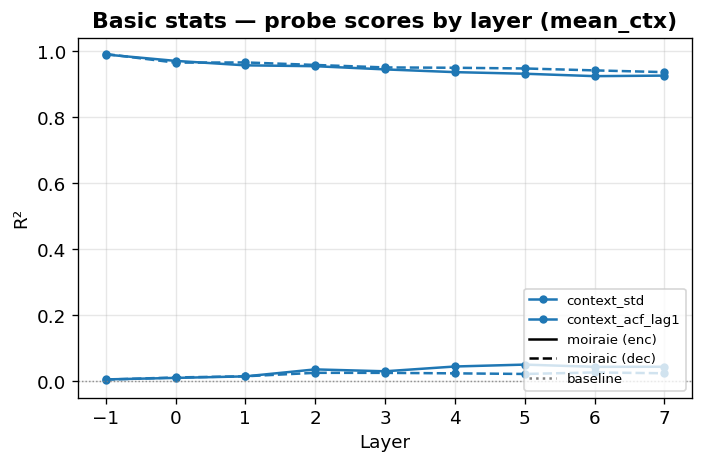

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_group_sanity.pdf


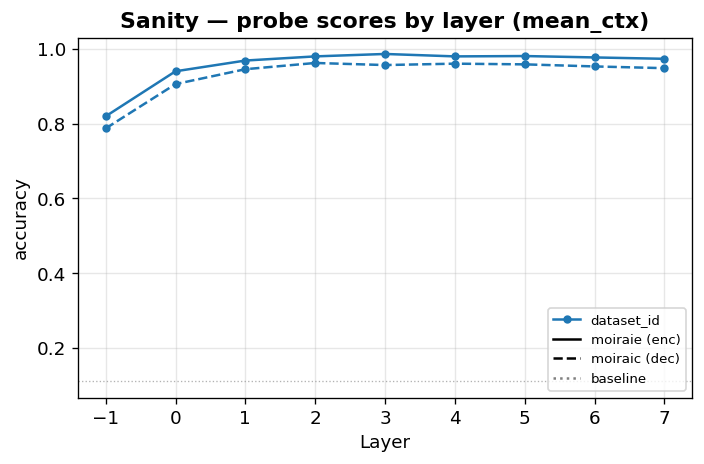

In [5]:
if not RESULTS_READY:
    print('No results yet — skipping.')
else:
    POOLING = 'mean_ctx'
    group_colors = plt.cm.tab10(np.linspace(0, 0.9, 12))

    for group_name, group_features in FEATURE_GROUPS.items():
        if not group_features:
            continue
        fig, ax = plt.subplots(figsize=(6, 4))

        for fi, feat in enumerate(group_features):
            meta = feature_meta[feat]
            baseline = meta['baseline']
            color = group_colors[fi % len(group_colors)]

            for m, ls in [('moiraie', '-'), ('moiraic', '--')]:
                if feat not in data[m][POOLING]:
                    continue
                scores = [data[m][POOLING][feat].get(l, np.nan) for l in LAYERS]
                label = f'{feat} / {m.replace("moira", "")}' if fi == 0 else None
                ax.plot(LAYERS, scores, linestyle=ls, marker='o', markersize=4,
                        color=color,
                        label=feat if m == 'moiraie' else None)

            # Baseline tick (use first feature's baseline; all regression → 0)
            ax.axhline(baseline, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)

        # Legend: feature colors + linestyle key
        handles, labels = ax.get_legend_handles_labels()
        handles += [
            Line2D([0], [0], color='black', linestyle='-',  label='moiraie (enc)'),
            Line2D([0], [0], color='black', linestyle='--', label='moiraic (dec)'),
            Line2D([0], [0], color='gray',  linestyle=':',  label='baseline'),
        ]
        ax.legend(handles=handles, fontsize=8, loc='lower right')
        ax.set_xlabel('Layer')
        ax.set_ylabel(feature_meta[group_features[0]]['metric'])
        ax.set_title(f'{group_name} — probe scores by layer ({POOLING})', fontweight='bold')
        ax.set_xticks(LAYERS)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()

        slug = group_name.lower().replace(' ', '_').replace('/', '')
        save_path = FIGURES_DIR / f'pr11_group_{slug}.pdf'
        fig.savefig(save_path, bbox_inches='tight')
        print(f'Saved {save_path}')
        plt.show()
        plt.close(fig)

## 4. Dataset-ID sanity probe

`dataset_id` is a 9-class probe: can the model linearly separate the 9 GIFT-Eval source datasets?
Chance = 1/9 ≈ 0.111. High accuracy means the model encodes dataset identity in its residual stream.

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_dataset_id_probe.pdf


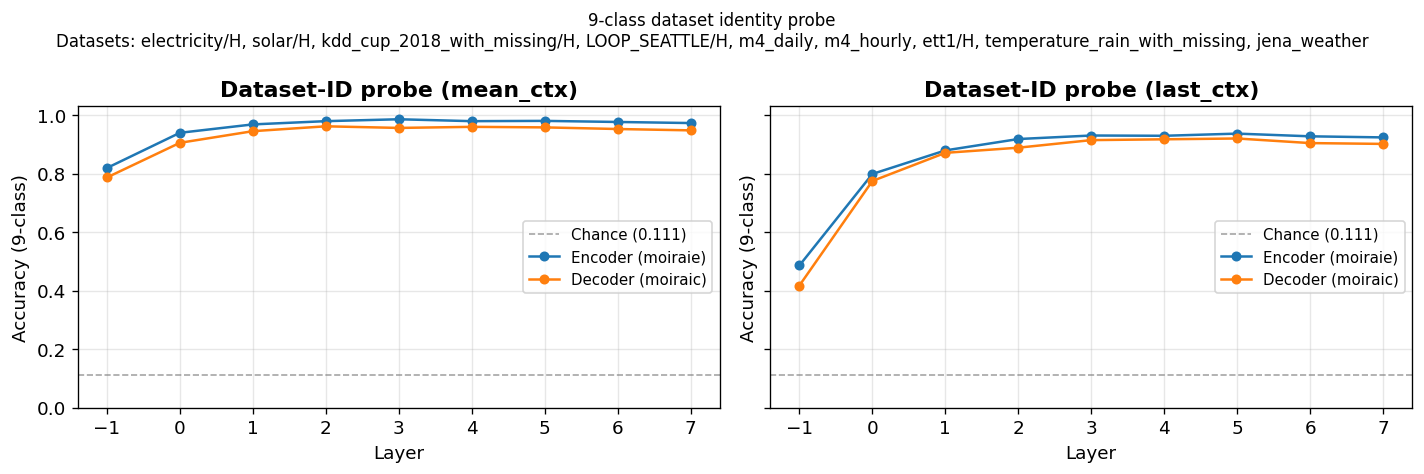

In [6]:
if not RESULTS_READY:
    print('No results yet — skipping.')
elif 'dataset_id' not in ALL_FEATURES:
    print('dataset_id not in results — skipping.')
else:
    from experiments.mech_interp.lib.real_data import GIFT_DATASETS

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    CHANCE = feature_meta['dataset_id']['baseline']

    for ax, pooling in zip(axes, POOLINGS):
        ax.axhline(CHANCE, color='gray', linestyle='--', linewidth=1, alpha=0.7,
                   label=f'Chance ({CHANCE:.3f})')
        for m in MODELS:
            if 'dataset_id' not in data[m][pooling]:
                continue
            scores = [data[m][pooling]['dataset_id'].get(l, np.nan) for l in LAYERS]
            ax.plot(LAYERS, scores, marker='o', markersize=5,
                    color=MODEL_COLORS[m], label=MODEL_LABELS[m])
        ax.set_xlabel('Layer')
        ax.set_ylabel('Accuracy (9-class)')
        ax.set_title(f'Dataset-ID probe ({pooling})', fontweight='bold')
        ax.set_xticks(LAYERS)
        ax.set_ylim(bottom=0)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    fig.suptitle(f'9-class dataset identity probe\n'
                 f'Datasets: {", ".join(GIFT_DATASETS)}', fontsize=10)
    plt.tight_layout()
    save_path = FIGURES_DIR / 'pr11_dataset_id_probe.pdf'
    fig.savefig(save_path, bbox_inches='tight')
    print(f'Saved {save_path}')
    plt.show()

## 5. mean_ctx vs last_ctx comparison

Scatter: x = mean_ctx best-layer score, y = last_ctx best-layer score, one point per (model, feature).
Points above the diagonal = last token is more informative than the mean.

moiraie: 0/12 features better with last_ctx
moiraic: 0/12 features better with last_ctx
Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_pooling_comparison.pdf


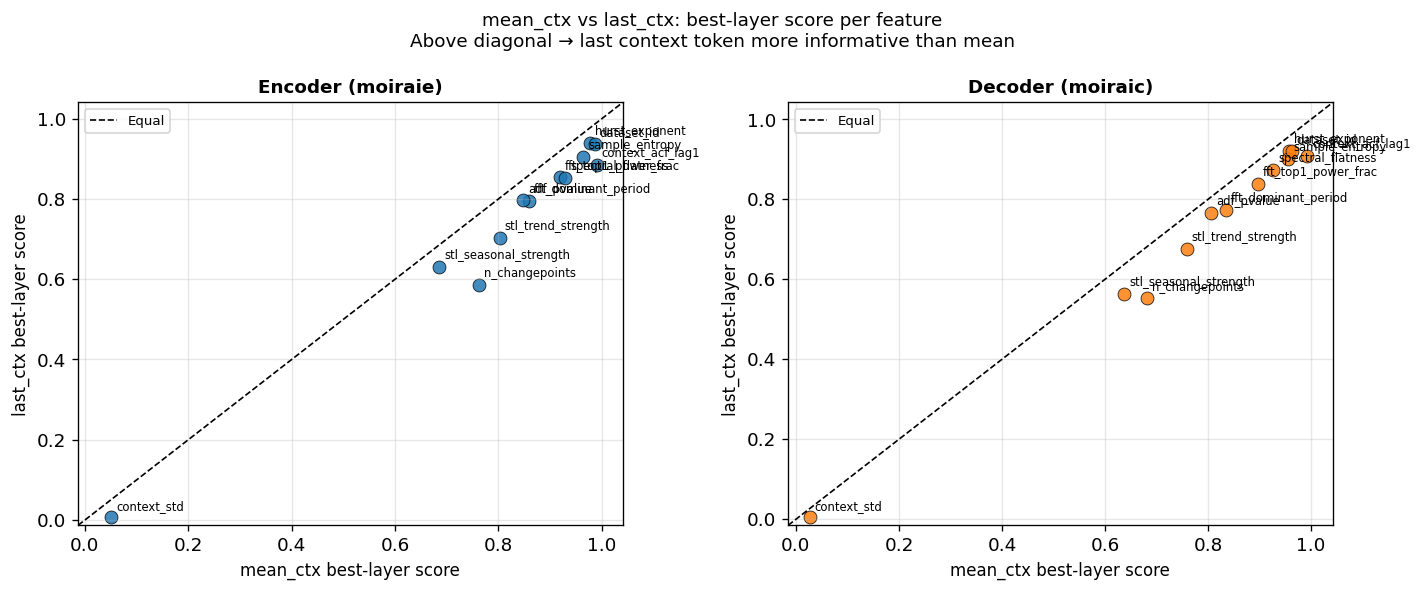

In [7]:
if not RESULTS_READY:
    print('No results yet — skipping.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, m in zip(axes, MODELS):
        xs, ys, labels_xy = [], [], []
        for feat in ALL_FEATURES:
            mean_scores = data[m]['mean_ctx'].get(feat, {})
            last_scores = data[m]['last_ctx'].get(feat, {})
            if not mean_scores or not last_scores:
                continue
            xs.append(max(mean_scores.values()))
            ys.append(max(last_scores.values()))
            labels_xy.append(feat)

        xs, ys = np.array(xs), np.array(ys)
        ax.scatter(xs, ys, s=60, alpha=0.85, color=MODEL_COLORS[m],
                   edgecolors='black', linewidths=0.5)
        for x, y, lbl in zip(xs, ys, labels_xy):
            ax.annotate(lbl, (x, y), fontsize=7, ha='left', va='bottom',
                        xytext=(3, 3), textcoords='offset points')

        lim_lo = min(xs.min(), ys.min()) - 0.02
        lim_hi = max(xs.max(), ys.max()) + 0.05
        ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=1, label='Equal')
        ax.set_xlim(lim_lo, lim_hi)
        ax.set_ylim(lim_lo, lim_hi)
        ax.set_xlabel('mean_ctx best-layer score', fontsize=10)
        ax.set_ylabel('last_ctx best-layer score', fontsize=10)
        ax.set_title(MODEL_LABELS[m], fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        above = (ys > xs).sum()
        print(f'{m}: {above}/{len(xs)} features better with last_ctx')

    fig.suptitle('mean_ctx vs last_ctx: best-layer score per feature\n'
                 'Above diagonal → last context token more informative than mean',
                 fontsize=11)
    plt.tight_layout()
    save_path = FIGURES_DIR / 'pr11_pooling_comparison.pdf'
    fig.savefig(save_path, bbox_inches='tight')
    print(f'Saved {save_path}')
    plt.show()

## 6. Encoder vs decoder: best-layer score per feature

Scatter across features: x = moiraie (encoder) best-layer score, y = moiraic (decoder).
Points above the diagonal = decoder encodes this feature better.

mean_ctx: decoder better in 1/12 features
Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_enc_vs_dec_mean_ctx.pdf


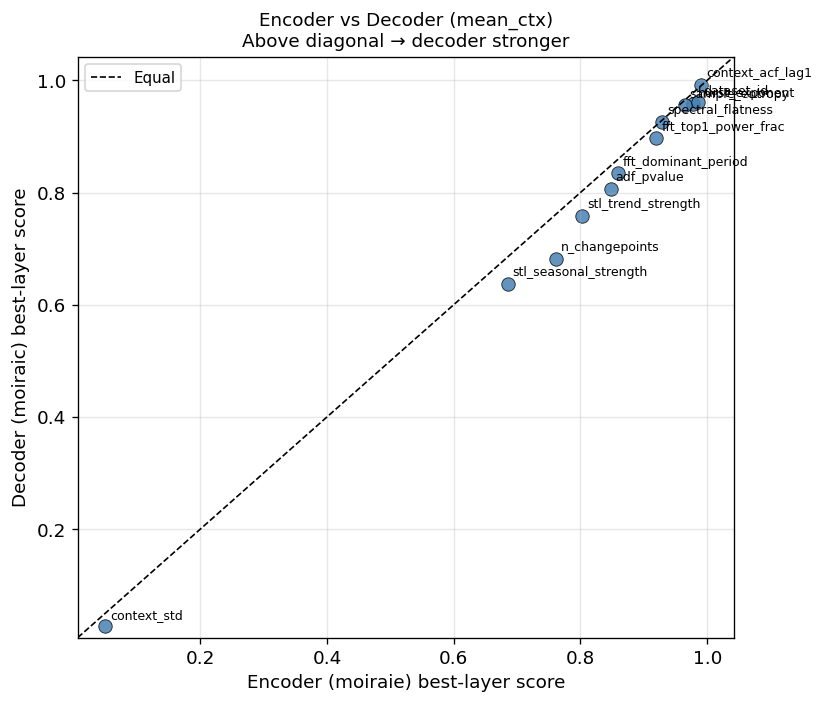

last_ctx: decoder better in 2/12 features
Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_enc_vs_dec_last_ctx.pdf


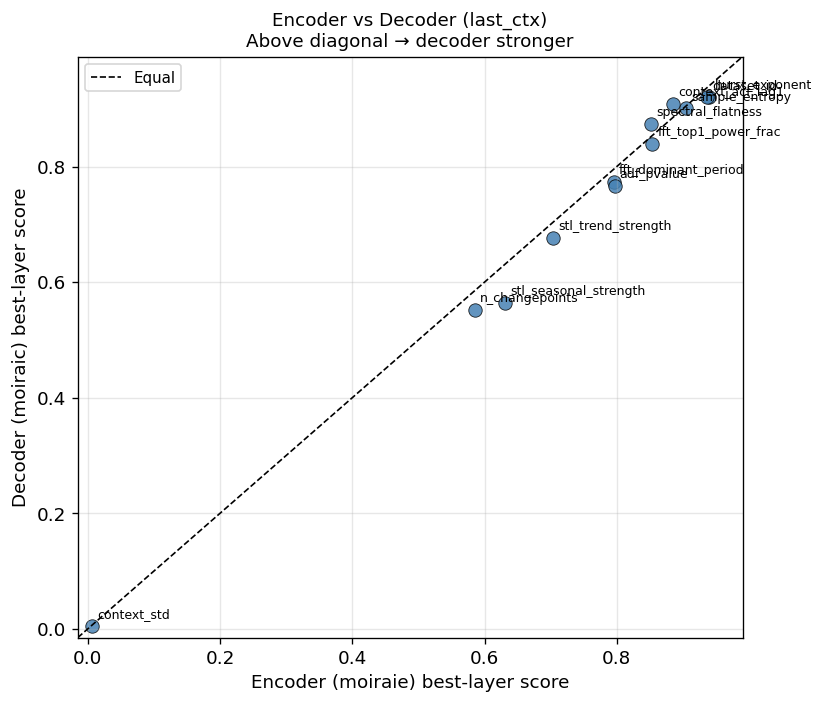

In [8]:
if not RESULTS_READY:
    print('No results yet — skipping.')
else:
    for pooling in POOLINGS:
        e_scores, c_scores, feat_labels = [], [], []
        for feat in ALL_FEATURES:
            e = data['moiraie'][pooling].get(feat, {})
            c = data['moiraic'][pooling].get(feat, {})
            if not e or not c:
                continue
            e_scores.append(max(e.values()))
            c_scores.append(max(c.values()))
            feat_labels.append(feat)

        e_arr, c_arr = np.array(e_scores), np.array(c_scores)
        fig, ax = plt.subplots(figsize=(7, 6))

        ax.scatter(e_arr, c_arr, s=65, alpha=0.85,
                   edgecolors='black', linewidths=0.5, color='steelblue')
        for x, y, lbl in zip(e_arr, c_arr, feat_labels):
            ax.annotate(lbl, (x, y), fontsize=7.5, ha='left', va='bottom',
                        xytext=(3, 3), textcoords='offset points')

        lim_lo = min(e_arr.min(), c_arr.min()) - 0.02
        lim_hi = max(e_arr.max(), c_arr.max()) + 0.05
        ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=1, label='Equal')
        ax.set_xlim(lim_lo, lim_hi)
        ax.set_ylim(lim_lo, lim_hi)
        ax.set_xlabel('Encoder (moiraie) best-layer score', fontsize=11)
        ax.set_ylabel('Decoder (moiraic) best-layer score', fontsize=11)
        ax.set_title(f'Encoder vs Decoder ({pooling})\n'
                     'Above diagonal → decoder stronger', fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()

        save_path = FIGURES_DIR / f'pr11_enc_vs_dec_{pooling}.pdf'
        fig.savefig(save_path, bbox_inches='tight')
        above = (c_arr > e_arr).sum()
        print(f'{pooling}: decoder better in {above}/{len(e_arr)} features')
        print(f'Saved {save_path}')
        plt.show()
        plt.close(fig)

## 7. Layer emergence curves: peak score vs. layer depth

For each feature, normalise scores by the best score across all layers → shows *where* in the network information peaks, independent of absolute magnitude.

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_layer_emergence.pdf


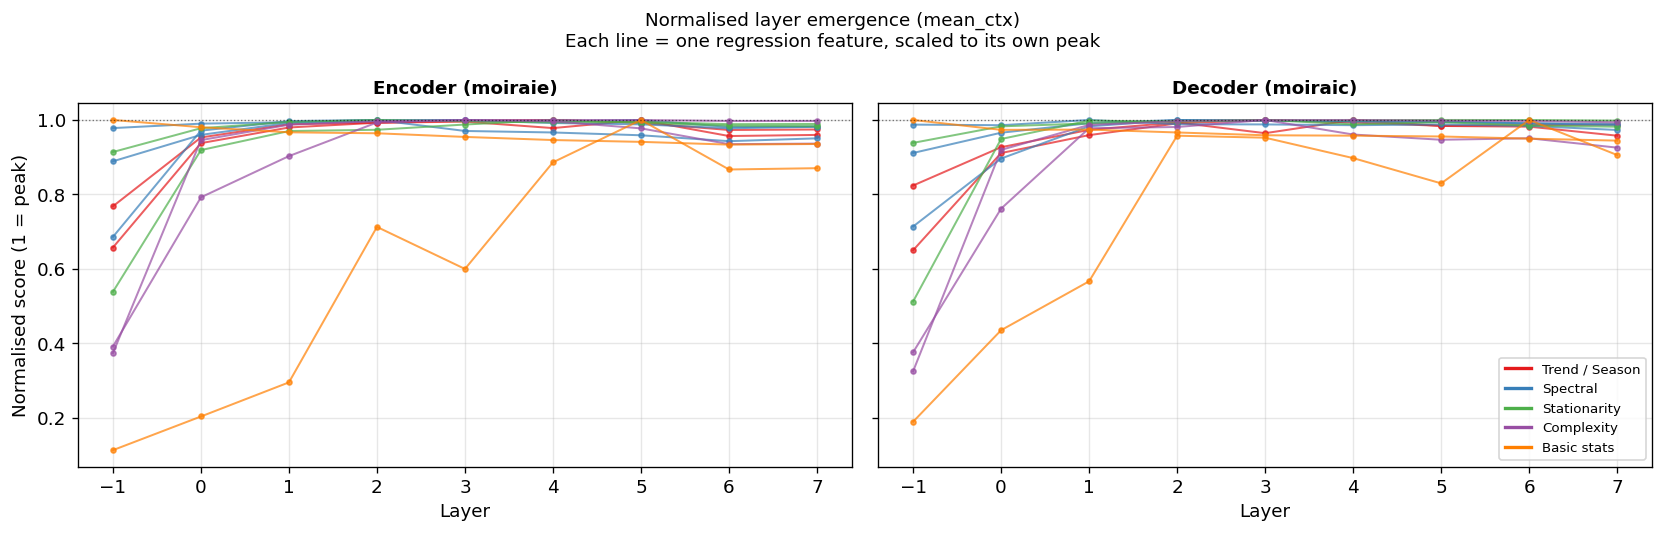

In [9]:
if not RESULTS_READY:
    print('No results yet — skipping.')
else:
    POOLING = 'mean_ctx'
    REG_FEATURES = [f for f in ALL_FEATURES if feature_meta[f]['type'] == 'regression']

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
    group_palette = {
        'Trend / Season': '#e41a1c',
        'Spectral':       '#377eb8',
        'Stationarity':   '#4daf4a',
        'Complexity':     '#984ea3',
        'Basic stats':    '#ff7f00',
    }
    feat_to_group = {f: g for g, fs in FEATURE_GROUPS.items() for f in fs}

    for ax, m in zip(axes, MODELS):
        for feat in REG_FEATURES:
            if feat not in data[m][POOLING]:
                continue
            scores = np.array([data[m][POOLING][feat].get(l, np.nan) for l in LAYERS],
                              dtype=float)
            peak = np.nanmax(scores)
            if peak <= 0:
                continue
            normed = scores / peak
            group = feat_to_group.get(feat, 'Basic stats')
            color = group_palette.get(group, 'gray')
            ax.plot(LAYERS, normed, marker='o', markersize=3, alpha=0.7,
                    color=color, linewidth=1.2)

        ax.axhline(1.0, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
        ax.set_xlabel('Layer')
        ax.set_ylabel('Normalised score (1 = peak)' if m == MODELS[0] else '')
        ax.set_title(MODEL_LABELS[m], fontsize=11, fontweight='bold')
        ax.set_xticks(LAYERS)
        ax.grid(True, alpha=0.3)

    legend_handles = [Line2D([0], [0], color=c, lw=2, label=g)
                      for g, c in group_palette.items()]
    axes[1].legend(handles=legend_handles, fontsize=8, loc='lower right')
    fig.suptitle(f'Normalised layer emergence ({POOLING})\n'
                 'Each line = one regression feature, scaled to its own peak',
                 fontsize=11)
    plt.tight_layout()
    save_path = FIGURES_DIR / 'pr11_layer_emergence.pdf'
    fig.savefig(save_path, bbox_inches='tight')
    print(f'Saved {save_path}')
    plt.show()

## 8. Summary table

In [10]:
if not RESULTS_READY:
    print('No results yet — skipping.')
else:
    rows = []
    for feat in ALL_FEATURES:
        meta = feature_meta[feat]
        group = next((g for g, fs in FEATURE_GROUPS.items() if feat in fs), '—')
        for m in MODELS:
            for pooling in POOLINGS:
                layer_scores = data[m][pooling].get(feat)
                if not layer_scores:
                    continue
                best_layer = max(layer_scores, key=layer_scores.get)
                peak = layer_scores[best_layer]
                rows.append({
                    'Group':        group,
                    'Feature':      feat,
                    'Model':        m,
                    'Pooling':      pooling,
                    'Metric':       meta['metric'],
                    'Baseline':     round(meta['baseline'], 4),
                    'Best layer':   best_layer,
                    'Peak score':   round(peak, 4),
                    'Δ baseline':   round(peak - meta['baseline'], 4),
                })

    df = pd.DataFrame(rows)
    df = df.sort_values(['Group', 'Feature', 'Model', 'Pooling'])

    summary_path = FIGURES_DIR / 'pr11_summary.csv'
    df.to_csv(summary_path, index=False)
    print(f'Summary saved to {summary_path}')

    # Display pivot: feature × model for mean_ctx only
    pivot = df[df['Pooling'] == 'mean_ctx'].pivot_table(
        index=['Group', 'Feature'], columns='Model',
        values=['Peak score', 'Best layer', 'Δ baseline']
    ).round(4)
    display(pivot)

Summary saved to /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr11_summary.csv


Best layer         Peak score          \
Model                                   moiraic moiraie    moiraic moiraie   
Group          Feature                                                       
Basic stats    context_acf_lag1            -1.0    -1.0     0.9921  0.9904   
               context_std                  6.0     5.0     0.0268  0.0506   
Complexity     n_changepoints               3.0     3.0     0.6819  0.7616   
               sample_entropy               4.0     4.0     0.9557  0.9644   
Sanity         dataset_id                   2.0     3.0     0.9620  0.9861   
Spectral       fft_dominant_period          2.0     5.0     0.8346  0.8589   
               fft_top1_power_frac          2.0     2.0     0.8969  0.9196   
               spectral_flatness            1.0     2.0     0.9262  0.9295   
Stationarity   adf_pvalue                   3.0     4.0     0.8063  0.8476   
               hurst_exponent               5.0     2.0     0.9573  0.9775   
Trend / Season stl_seasonal_strength        4.0     5.0     0.6371  0.6852   
               stl_trend_strength           3.0     4.0     0.7584  0.8022   

                                     Δ baseline          
Model                                   moiraic moiraie  
Group          Feature                                   
Basic stats    context_acf_lag1          0.9921  0.9904  
               context_std               0.0268  0.0506  
Complexity     n_changepoints            0.6819  0.7616  
               sample_entropy            0.9557  0.9644  
Sanity         dataset_id                0.8509  0.8750  
Spectral       fft_dominant_period       0.8346  0.8589  
               fft_top1_power_frac       0.8969  0.9196  
               spectral_flatness         0.9262  0.9295  
Stationarity   adf_pvalue                0.8063  0.8476  
               hurst_exponent            0.9573  0.9775  
Trend / Season stl_seasonal_strength     0.6371  0.6852  
               stl_trend_strength        0.7584  0.8022